<a href="https://colab.research.google.com/github/darreneasler/MiniProject03/blob/main/MiniProject3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
#Import Libraries and Data

import numpy as np
import matplotlib as plt
import pandas as pd
import gdown
import seaborn as sns

print("seaborn", sns.__version__)
print()
print("pandas", pd.__version__)
print()
print("numpy", np.__version__)
print()
print("matplotlib", plt.__version__)
print()

csv_id = "1_kBYuGnlH1KBZ5O-7aS_910gyhB6sO9T"
url = f"https://drive.google.com/uc?id={csv_id}"
gdown.download(url, "car details v4.csv", quiet=False)

print()
dataset = pd.read_csv("car details v4.csv")
print(dataset.shape)
print()
dataset.head()

seaborn 0.13.2

pandas 2.2.2

numpy 2.0.2

matplotlib 3.10.0



Downloading...
From: https://drive.google.com/uc?id=1_kBYuGnlH1KBZ5O-7aS_910gyhB6sO9T
To: /content/car details v4.csv
100%|██████████| 333k/333k [00:00<00:00, 6.52MB/s]



(2059, 20)



,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [79]:
#Missing Values

missing = dataset.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
Drivetrain            136
Fuel Tank Capacity    113
Engine                 80
Max Torque             80
Max Power              80
Length                 64
Width                  64
Height                 64
Seating Capacity       64
dtype: int64


In [80]:
#Setting Predictors and Target

target = ["Price"]
predictors = ["Year", "Make", "Model", "Kilometer", "Engine", "Max Power", "Transmission", "Fuel Type", "Owner", "Location"]

dataset = dataset[predictors + target]
print(dataset.head())
print()
print(dataset.isnull().sum())
print()

both_missing = dataset[dataset["Engine"].isna() & dataset["Max Power"].isna()]
print(f"Rows where both Engine and Max Power are missing: {len(both_missing)}")

   Year           Make                            Model  Kilometer   Engine  \
0  2017          Honda              Amaze 1.2 VX i-VTEC      87150  1198 cc   
1  2014  Maruti Suzuki                  Swift DZire VDI      75000  1248 cc   
2  2011        Hyundai             i10 Magna 1.2 Kappa2      67000  1197 cc   
3  2019         Toyota                         Glanza G      37500  1197 cc   
4  2018         Toyota  Innova 2.4 VX 7 STR [2016-2020]      69000  2393 cc   

            Max Power Transmission Fuel Type   Owner   Location    Price  
0   87 bhp @ 6000 rpm       Manual    Petrol   First       Pune   505000  
1   74 bhp @ 4000 rpm       Manual    Diesel  Second   Ludhiana   450000  
2   79 bhp @ 6000 rpm       Manual    Petrol   First    Lucknow   220000  
3   82 bhp @ 6000 rpm       Manual    Petrol   First  Mangalore   799000  
4  148 bhp @ 3400 rpm       Manual    Diesel   First     Mumbai  1950000  

Year             0
Make             0
Model            0
Kilometer        

In [81]:
#Fixing Missing Values

dataset = dataset.dropna(subset=["Engine", "Max Power"])

print(dataset.shape)
print()
print(dataset.isnull().sum())
print()
print(dataset.info())



(1979, 11)

Year            0
Make            0
Model           0
Kilometer       0
Engine          0
Max Power       0
Transmission    0
Fuel Type       0
Owner           0
Location        0
Price           0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Index: 1979 entries, 0 to 2058
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          1979 non-null   int64 
 1   Make          1979 non-null   object
 2   Model         1979 non-null   object
 3   Kilometer     1979 non-null   int64 
 4   Engine        1979 non-null   object
 5   Max Power     1979 non-null   object
 6   Transmission  1979 non-null   object
 7   Fuel Type     1979 non-null   object
 8   Owner         1979 non-null   object
 9   Location      1979 non-null   object
 10  Price         1979 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 185.5+ KB
None


In [82]:
#Fixing Engine and Max Power

dataset["Engine"] = (dataset["Engine"].astype(str).str.extract(r'(\d+)').astype(int))
dataset["Max Power"] = (dataset["Max Power"].astype(str).str.extract(r'(\d+\.?\d*)').astype(float))

print(dataset.info())

dataset.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1979 entries, 0 to 2058
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          1979 non-null   int64  
 1   Make          1979 non-null   object 
 2   Model         1979 non-null   object 
 3   Kilometer     1979 non-null   int64  
 4   Engine        1979 non-null   int64  
 5   Max Power     1979 non-null   float64
 6   Transmission  1979 non-null   object 
 7   Fuel Type     1979 non-null   object 
 8   Owner         1979 non-null   object 
 9   Location      1979 non-null   object 
 10  Price         1979 non-null   int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 185.5+ KB
None


,Year,Make,Model,Kilometer,Engine,Max Power,Transmission,Fuel Type,Owner,Location,Price
0,2017,Honda,Amaze 1.2 VX i-VTEC,87150,1198,87.0,Manual,Petrol,First,Pune,505000
1,2014,Maruti Suzuki,Swift DZire VDI,75000,1248,74.0,Manual,Diesel,Second,Ludhiana,450000
2,2011,Hyundai,i10 Magna 1.2 Kappa2,67000,1197,79.0,Manual,Petrol,First,Lucknow,220000
3,2019,Toyota,Glanza G,37500,1197,82.0,Manual,Petrol,First,Mangalore,799000
4,2018,Toyota,Innova 2.4 VX 7 STR [2016-2020],69000,2393,148.0,Manual,Diesel,First,Mumbai,1950000


In [83]:
#Split Features and Target

X = dataset.drop("Price", axis=1)
Y = dataset["Price"]

print(X.head())
print()
print(Y.head())

   Year           Make                            Model  Kilometer  Engine  \
0  2017          Honda              Amaze 1.2 VX i-VTEC      87150    1198   
1  2014  Maruti Suzuki                  Swift DZire VDI      75000    1248   
2  2011        Hyundai             i10 Magna 1.2 Kappa2      67000    1197   
3  2019         Toyota                         Glanza G      37500    1197   
4  2018         Toyota  Innova 2.4 VX 7 STR [2016-2020]      69000    2393   

   Max Power Transmission Fuel Type   Owner   Location  
0       87.0       Manual    Petrol   First       Pune  
1       74.0       Manual    Diesel  Second   Ludhiana  
2       79.0       Manual    Petrol   First    Lucknow  
3       82.0       Manual    Petrol   First  Mangalore  
4      148.0       Manual    Diesel   First     Mumbai  

0     505000
1     450000
2     220000
3     799000
4    1950000
Name: Price, dtype: int64


In [84]:
#Numerical Shift for Ridge Regression

cat_cols = ["Make", "Model", "Transmission", "Fuel Type", "Owner", "Location"]

X = pd.get_dummies(X, columns = cat_cols, drop_first = True)
print(X.shape)

for col in cat_cols:
    print(col, dataset[col].nunique())


(1979, 1127)
Make 33
Model 1005
Transmission 2
Fuel Type 7
Owner 6
Location 76


In [85]:
#Split Data

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)


(1583, 1127)
(396, 1127)
(1583,)
(396,)


In [86]:
#Ridge Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [87]:
#Ridge Model

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=67)
ridge_model.fit(X_train_scaled, Y_train)

Y_pred = ridge_model.predict(X_test_scaled)



MAE: 401629.91
RMSE: 809180.04
R²: 0.832


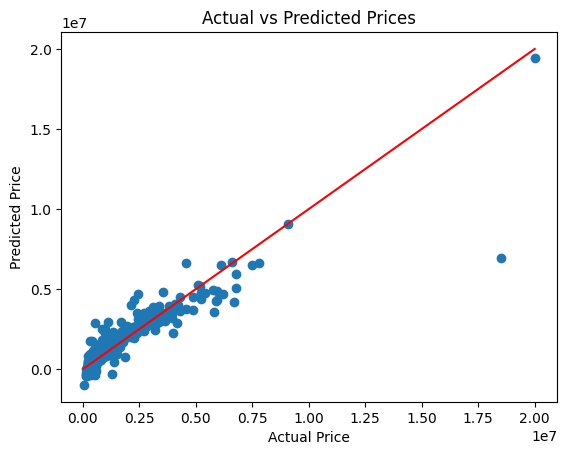

In [88]:
#Model Evaluation

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f"MAE: {mean_absolute_error(Y_test, Y_pred):.2f}")
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2_score(Y_test, Y_pred):.3f}")

plt.scatter(Y_test, Y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color="red")

plt.show()

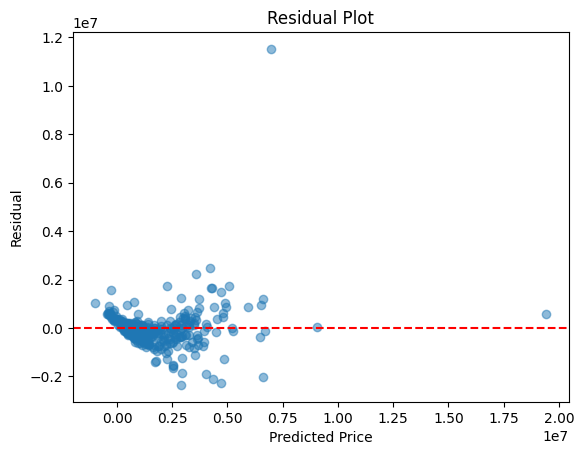

In [89]:
#Residual Plot

residuals = Y_test - Y_pred

plt.scatter(Y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()